In [1]:
import pandas as pd

inventory_df = pd.read_csv("InventoryStockMovement_Cleaned.csv")

print(inventory_df.shape)
print(inventory_df.columns.tolist())
inventory_df.info()
inventory_df.head()

(2036, 9)
['Product_ID', 'Warehouse_ID', 'Category', 'Stock_On_Hand', 'Reorder_Level', 'Reorder_Flag', 'Avg_Lead_Time_Days', 'Stockout_Days', 'Carrying_Cost_Per_Unit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2036 entries, 0 to 2035
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Product_ID              2036 non-null   int64  
 1   Warehouse_ID            2036 non-null   object 
 2   Category                2036 non-null   object 
 3   Stock_On_Hand           2036 non-null   int64  
 4   Reorder_Level           2036 non-null   int64  
 5   Reorder_Flag            2036 non-null   int64  
 6   Avg_Lead_Time_Days      2036 non-null   int64  
 7   Stockout_Days           2036 non-null   int64  
 8   Carrying_Cost_Per_Unit  2036 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 143.3+ KB


,Product_ID,Warehouse_ID,Category,Stock_On_Hand,Reorder_Level,Reorder_Flag,Avg_Lead_Time_Days,Stockout_Days,Carrying_Cost_Per_Unit
0,1698815,PLANT15,Misc,149,10,0,5,0,0.28
1,1664419,PLANT17,Misc,6,10,1,5,1,0.09
2,1664426,PLANT17,Misc,6,10,1,5,1,0.09
3,1672826,PLANT17,Misc,6,10,1,5,2,0.09
4,1674916,PLANT17,Misc,6,10,1,5,3,0.09


# Step 2: Data Quality Assessment

The objective of this step is to identify any missing values, duplicate records, invalid values, and understand the statistical distribution of the data. High-quality data ensures that the analysis is reliable and supports accurate business decision-making.

In [2]:

# Check for Missing Values


# Display the number of missing values in each column
inventory_df.isnull().sum()

,0
Product_ID,0
Warehouse_ID,0
Category,0
Stock_On_Hand,0
Reorder_Level,0
Reorder_Flag,0
Avg_Lead_Time_Days,0
Stockout_Days,0
Carrying_Cost_Per_Unit,0


In [3]:

# Check for Duplicate Records

# Count duplicate rows in the dataset
inventory_df.duplicated().sum()

np.int64(0)

In [4]:

# Descriptive Statistics

# Display summary statistics for numerical columns
inventory_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_ID,2036.0,1.684180e+06,13148.043792,1613321.0,1680697.0,1685269.5,1692998.75,1702654.00
Stock_On_Hand,2036.0,8.042191e+01,186.046530,0.0,20.0,20.0,85.00,3385.00
Reorder_Level,2036.0,8.041257e+00,7.626365,0.0,3.0,10.0,10.00,35.00
Reorder_Flag,2036.0,1.031434e-02,0.101059,0.0,0.0,0.0,0.00,1.00
Avg_Lead_Time_Days,2036.0,5.000000e+00,0.000000,5.0,5.0,5.0,5.00,5.00
Stockout_Days,2036.0,1.915521e-02,0.208249,0.0,0.0,0.0,0.00,3.00
Carrying_Cost_Per_Unit,2036.0,1.185707e-01,0.068646,0.0,0.1,0.1,0.11,0.41


### Interpretation

The descriptive statistics provide an overview of the numerical variables in the inventory dataset.

Key observations:

- The dataset contains **2,036 inventory records**.
- The average stock available (`Stock_On_Hand`) is **80.42 units**, while the maximum stock reaches **3,385 units**, indicating considerable variation in inventory levels.
- The average reorder level is approximately **8 units**, with values ranging from **0 to 35 units**.
- The `Reorder_Flag` has an average value of **0.01**, indicating that only a small proportion of products currently require replenishment.
- The average lead time is **5 days** for all products, showing consistent supplier delivery times.
- The average stockout duration is **0.02 days**, suggesting that stock shortages are relatively rare.
- The average carrying cost per unit is **0.12**, with a maximum of **0.41**, indicating variation in inventory holding costs across products.

Overall, the statistics suggest that the inventory dataset is well-balanced, although stock quantities vary considerably among products.

**Business Insight:**

The organisation maintains generally healthy inventory levels with very few products requiring immediate replenishment. However, the large variation in stock quantities suggests that inventory optimisation opportunities exist, particularly for products with excessively high stock levels, which may increase carrying costs.

In [5]:

# Count Unique Values


# Display the number of unique values in each column
inventory_df.nunique()

,0
Product_ID,1540
Warehouse_ID,19
Category,1
Stock_On_Hand,18
Reorder_Level,7
Reorder_Flag,2
Avg_Lead_Time_Days,1
Stockout_Days,4
Carrying_Cost_Per_Unit,10


### Interpretation

The unique value analysis provides an understanding of the diversity of the inventory data.

Key observations:

- The dataset contains **1,540 unique products** distributed across **19 warehouses**.
- Only **one product category** is present (`Misc`), indicating that all inventory items belong to the same category.
- `Stock_On_Hand` has **18 unique values**, representing different inventory levels across products.
- `Reorder_Level` contains **7 distinct values**, showing that reorder thresholds vary for different products.
- `Reorder_Flag` contains **2 unique values (0 and 1)**, indicating whether a product requires replenishment.
- `Avg_Lead_Time_Days` has only **one unique value (5 days)**, meaning supplier lead time is constant throughout the dataset.
- `Stockout_Days` contains **4 unique values**, indicating different durations of stock shortages.
- `Carrying_Cost_Per_Unit` has **10 unique values**, reflecting different inventory holding costs among products.

**Business Insight:**

The inventory is distributed across multiple warehouses and a large number of products. However, since all products belong to a single category and have the same supplier lead time, future analysis should focus on stock levels, reorder patterns and carrying costs rather than product categories or supplier variability.

In [6]:

# Check for Negative Values

# Select all numerical columns
numeric_cols = inventory_df.select_dtypes(include=['int64', 'float64']).columns

# Count negative values in each numerical column
for col in numeric_cols:
    negative_count = (inventory_df[col] < 0).sum()
    print(f"{col}: {negative_count}")

Product_ID: 0
Stock_On_Hand: 0
Reorder_Level: 0
Reorder_Flag: 0
Avg_Lead_Time_Days: 0
Stockout_Days: 0
Carrying_Cost_Per_Unit: 0


# Step 3: Stock Availability Analysis

## Objective

The objective of this analysis is to evaluate the current inventory levels across products and warehouses.

This analysis helps identify:
- Products with high and low stock levels.
- Warehouses maintaining larger inventories.
- Overall stock distribution.
- Potential risks of inventory shortages or overstocking.

The insights obtained from this analysis support better inventory planning and warehouse management.

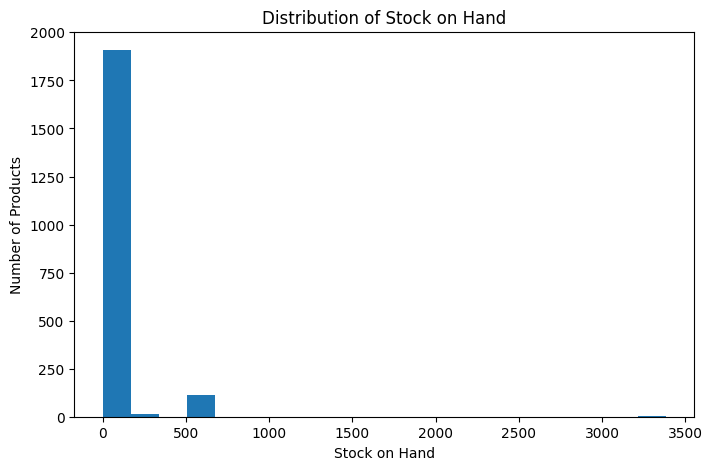

In [7]:

# Import Required Libraries

import matplotlib.pyplot as plt

# Distribution of Stock On Hand

plt.figure(figsize=(8,5))

plt.hist(inventory_df['Stock_On_Hand'], bins=20)

plt.title("Distribution of Stock on Hand")
plt.xlabel("Stock on Hand")
plt.ylabel("Number of Products")

plt.show()

### Interpretation

The histogram shows the distribution of stock available across all inventory items.

Key observations:

- The majority of products maintain relatively low stock levels, with most inventory concentrated below 100 units.
- A very small number of products have exceptionally high stock quantities, reaching up to **3,385 units**.
- The distribution is **positively (right) skewed**, indicating that only a few products contribute to very high inventory levels.

This suggests that inventory is unevenly distributed across products, with most products maintaining normal stock levels while a few products are heavily stocked.

**Business Insight**

The presence of a few products with extremely high stock levels may indicate overstocking, which can increase warehouse space utilization and inventory carrying costs. These products should be reviewed against demand forecasts to optimize inventory levels.

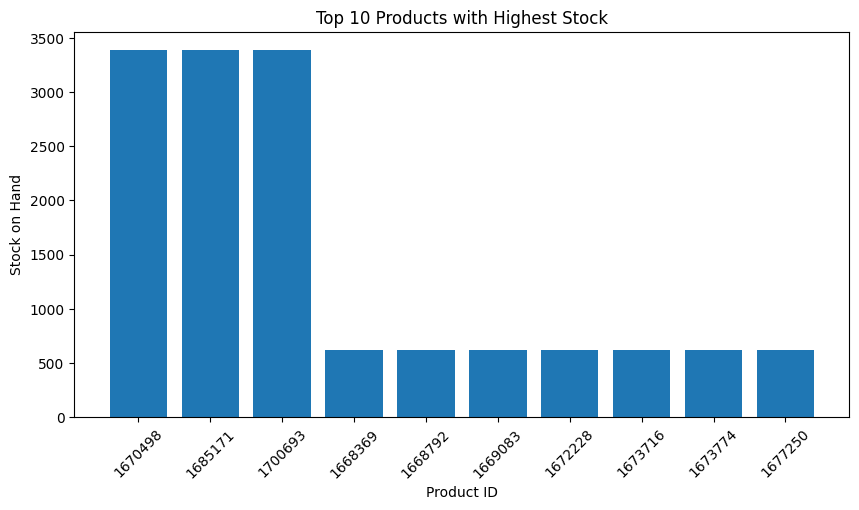

,Product_ID,Stock_On_Hand
673,1670498,3385
674,1685171,3385
675,1700693,3385
680,1668369,618
682,1668792,618
683,1669083,618
684,1672228,618
685,1673716,618
686,1673774,618
687,1677250,618


In [8]:

# Top 10 Products by Available Stock

top_stock = (
    inventory_df[['Product_ID', 'Stock_On_Hand']]
    .sort_values(by='Stock_On_Hand', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_stock['Product_ID'].astype(str),
    top_stock['Stock_On_Hand']
)

plt.title("Top 10 Products with Highest Stock")
plt.xlabel("Product ID")
plt.ylabel("Stock on Hand")

plt.xticks(rotation=45)

plt.show()

top_stock

### Interpretation

The chart identifies the ten products with the highest inventory levels.

Key observations:

- Products **1670498, 1685171, and 1700693** maintain the highest stock levels, with approximately **3,385 units** each.
- The remaining products in the top ten maintain inventory levels of approximately **620 units**.
- A significant gap exists between the top three products and the remaining products, indicating a concentration of inventory in only a few products.

This suggests that a small number of products occupy a substantial portion of the available warehouse inventory.

**Business Insight**

Products with exceptionally high stock should be evaluated to determine whether the inventory levels are driven by high demand or excess stocking. Maintaining excessive inventory increases carrying costs and warehouse occupancy.

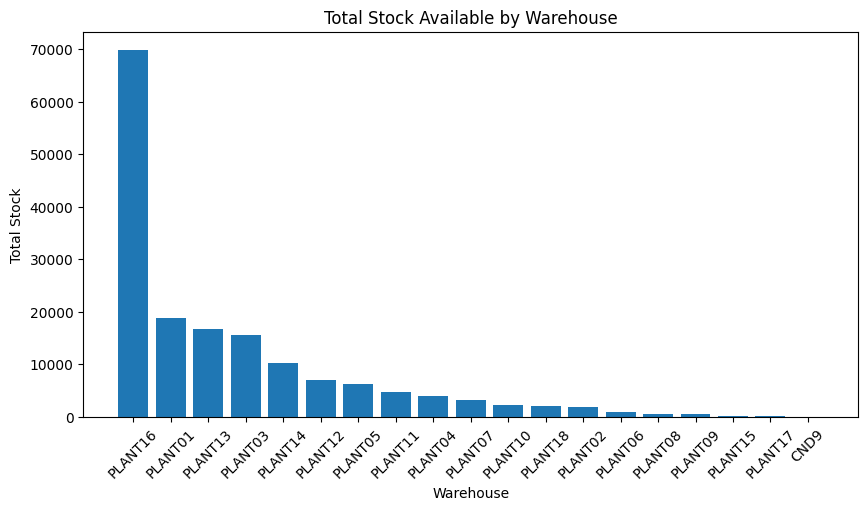

,Stock_On_Hand
Warehouse_ID,
PLANT16,69834
PLANT01,18700
PLANT13,16650
PLANT03,15620
PLANT14,10155
PLANT12,6897
PLANT05,6223
PLANT11,4608
PLANT04,3886


In [9]:

# Total Stock Available by Warehouse

warehouse_stock = (
    inventory_df
    .groupby('Warehouse_ID')['Stock_On_Hand']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(
    warehouse_stock.index,
    warehouse_stock.values
)

plt.title("Total Stock Available by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Stock")

plt.xticks(rotation=45)

plt.show()

warehouse_stock

### Interpretation

The warehouse-wise inventory analysis highlights the distribution of stock across all warehouses.

Key observations:

- **PLANT16** stores the highest inventory with **69,834 units**, significantly exceeding all other warehouses.
- **PLANT01, PLANT13, and PLANT03** maintain moderate inventory levels ranging from approximately **15,000 to 19,000 units**.
- Several warehouses such as **PLANT08, PLANT09, PLANT15, and PLANT17** maintain very low inventory levels.
- **CND9** currently contains **no inventory**, indicating that it is either inactive or not being utilized.

The results indicate an uneven distribution of inventory across warehouse locations.

**Business Insight**

The extremely high inventory stored in PLANT16 suggests that this warehouse acts as the primary storage facility. However, the imbalance in stock distribution may increase operational dependency on a single warehouse. Redistributing inventory among underutilized warehouses can improve storage utilization, reduce operational risks, and enhance inventory availability across locations.

# Stock Availability Analysis Summary

The stock availability analysis provided valuable insights into the current inventory distribution across products and warehouses.

### Key Findings

- Most products maintain relatively low inventory levels.
- Inventory distribution is positively skewed due to a few products with exceptionally high stock.
- Products **1670498, 1685171, and 1700693** have the highest stock quantities.
- **PLANT16** stores the largest share of inventory, while several warehouses maintain very limited stock.
- **CND9** currently contains no inventory.

Overall, the analysis indicates opportunities to improve inventory balancing across products and warehouses to optimize storage utilization and reduce carrying costs.

# Step 4: Reorder Trend Analysis

## Objective

The objective of this analysis is to identify products that require replenishment based on the reorder flag and reorder level.

Reorder analysis helps inventory managers monitor stock shortages, prevent stockouts, and ensure timely procurement of products.

The following analysis focuses on:

- Products requiring replenishment
- Distribution of reorder status
- Warehouse-wise reorder requirements
- Comparison of stock levels with reorder levels

In [10]:

# Products Requiring Reorder

# Count products that require reorder and those that do not
reorder_count = inventory_df["Reorder_Flag"].value_counts()

print(reorder_count)

Reorder_Flag
0    2015
1      21
Name: count, dtype: int64


### Interpretation

The reorder status analysis indicates the overall inventory replenishment requirements.

Key observations:

- Out of **2,036 products**, **2,015 products (98.97%)** have sufficient inventory and do not require immediate replenishment.
- Only **21 products (1.03%)** have been flagged for reorder.

The results suggest that the inventory is generally well-managed, with only a small percentage of products requiring restocking.

**Business Insight**

The low percentage of products requiring replenishment indicates effective inventory control and stock monitoring. Timely procurement of the identified 21 products will help prevent future stock shortages.

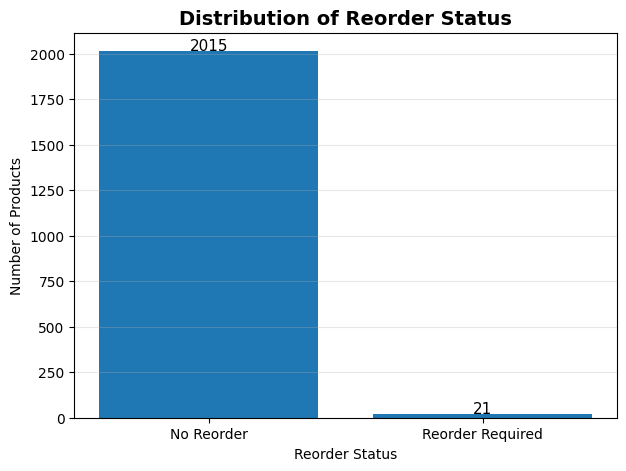

In [11]:

# Reorder Status Distribution

import matplotlib.pyplot as plt

# Count reorder status
reorder_count = inventory_df["Reorder_Flag"].value_counts()

# Labels
labels = ["No Reorder", "Reorder Required"]

plt.figure(figsize=(7,5))

bars = plt.bar(labels, reorder_count.values)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        str(int(height)),
        ha='center',
        fontsize=11
    )

plt.title("Distribution of Reorder Status", fontsize=14, weight="bold")
plt.xlabel("Reorder Status")
plt.ylabel("Number of Products")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

The bar chart illustrates the distribution of products based on their reorder status.

Key observations:

- The vast majority of products belong to the **No Reorder** category.
- Only a very small number of products fall under the **Reorder Required** category.

The chart confirms that current inventory levels are adequate for most products and that only limited replenishment activities are necessary.

**Business Insight**

Maintaining a low number of products requiring replenishment reflects efficient inventory planning. Regular monitoring of reorder status can help sustain this performance and minimise stockout risks.

In [12]:

# Products Below Reorder Level

below_reorder = inventory_df[
    inventory_df["Stock_On_Hand"] <= inventory_df["Reorder_Level"]
]

print("Products Below Reorder Level:", len(below_reorder))

below_reorder.head()

Products Below Reorder Level: 21


,Product_ID,Warehouse_ID,Category,Stock_On_Hand,Reorder_Level,Reorder_Flag,Avg_Lead_Time_Days,Stockout_Days,Carrying_Cost_Per_Unit
1,1664419,PLANT17,Misc,6,10,1,5,1,0.09
2,1664426,PLANT17,Misc,6,10,1,5,1,0.09
3,1672826,PLANT17,Misc,6,10,1,5,2,0.09
4,1674916,PLANT17,Misc,6,10,1,5,3,0.09
5,1674918,PLANT17,Misc,6,10,1,5,3,0.09


### Interpretation

The analysis identified **21 products** whose available stock is less than or equal to their predefined reorder level.

Key observations:

- All identified products require immediate replenishment.
- Several products belonging to **PLANT17** appear repeatedly, indicating that this warehouse has multiple low-stock items.
- Delayed replenishment of these products may lead to stockouts and affect inventory availability.

These products should be prioritised for procurement to maintain uninterrupted inventory operations.

**Business Insight**

Products below their reorder level represent the highest inventory risk. Prompt replenishment will reduce the likelihood of stock shortages and improve overall supply chain continuity.

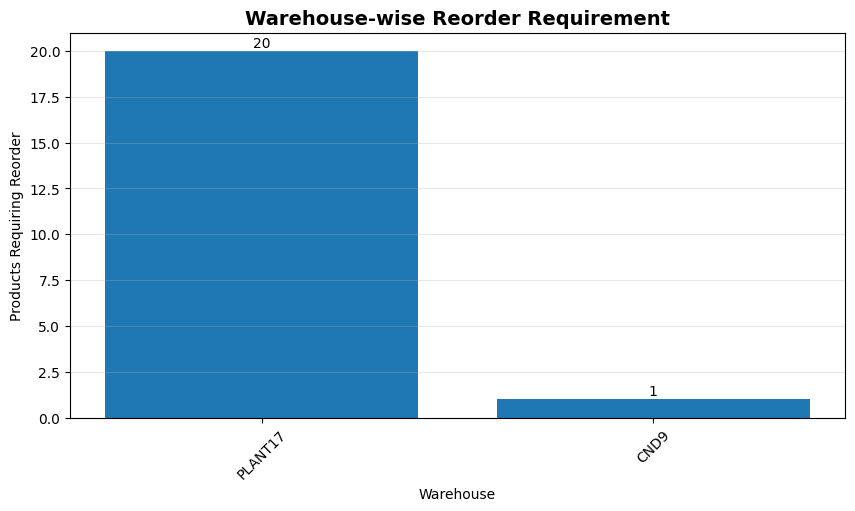

,0
Warehouse_ID,
PLANT17,20
CND9,1


In [13]:

# Warehouse-wise Reorder Requirement

warehouse_reorder = (
    inventory_df[inventory_df["Reorder_Flag"] == 1]
    .groupby("Warehouse_ID")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    warehouse_reorder.index,
    warehouse_reorder.values
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.2,
        int(bar.get_height()),
        ha='center',
        fontsize=10
    )

plt.title("Warehouse-wise Reorder Requirement",
          fontsize=14,
          weight='bold')

plt.xlabel("Warehouse")
plt.ylabel("Products Requiring Reorder")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

warehouse_reorder

### Interpretation

The warehouse-wise analysis identifies locations where products require replenishment.

Key observations:

- **PLANT17** accounts for **20 out of 21 products** requiring reorder.
- **CND9** contains only **one product** requiring replenishment.
- No other warehouse currently has products below the reorder threshold.

The results indicate that inventory shortages are concentrated primarily within PLANT17 rather than being distributed across multiple warehouses.

**Business Insight**

Inventory managers should prioritise replenishment activities at **PLANT17**, as it contains nearly all products requiring immediate restocking. Addressing shortages at this warehouse will significantly improve overall inventory availability.

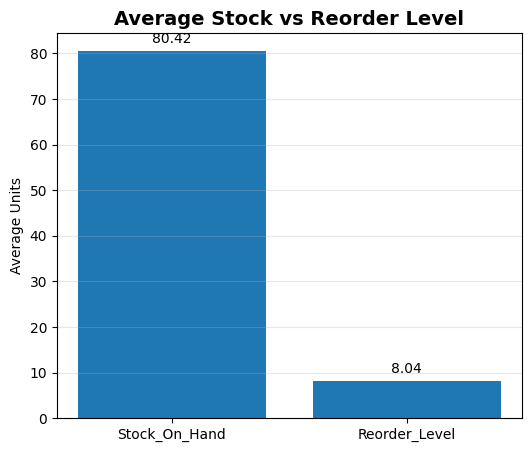

In [14]:

# Compare Average Stock and Reorder Level

comparison = inventory_df[
    ["Stock_On_Hand", "Reorder_Level"]
].mean()

plt.figure(figsize=(6,5))

bars = plt.bar(
    comparison.index,
    comparison.values
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+2,
        round(bar.get_height(),2),
        ha='center'
    )

plt.title("Average Stock vs Reorder Level",
          fontsize=14,
          weight='bold')

plt.ylabel("Average Units")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

The comparison between average stock levels and average reorder levels provides an overall view of inventory health.

Key observations:

- The average available stock is approximately **80.42 units**.
- The average reorder level is approximately **8.04 units**.
- The average inventory level is nearly **ten times greater** than the reorder threshold.

This indicates that the organisation generally maintains inventory well above the minimum required stock level.

**Business Insight**

Maintaining stock levels substantially above the reorder threshold reduces the likelihood of stock shortages. However, excessively high inventory should also be reviewed to balance inventory availability with carrying costs.

# Reorder Trend Analysis Summary

The reorder trend analysis evaluated inventory replenishment requirements using reorder flags and stock thresholds.

### Key Findings

- Only **21 out of 2,036 products** require immediate replenishment.
- Approximately **99% of products** maintain sufficient inventory levels.
- **PLANT17** is the primary warehouse requiring inventory replenishment.
- The average stock level (**80.42 units**) is significantly higher than the average reorder level (**8.04 units**).
- Overall inventory management appears effective, with only a small number of products requiring procurement.

The analysis indicates that the organisation has established strong inventory control practices while highlighting PLANT17 as the key focus area for immediate replenishment activities.

# Step 6: Carrying Cost Analysis

## Objective

The objective of this analysis is to evaluate the inventory carrying cost across products and warehouses.

Carrying cost represents the expense incurred while storing inventory. Analysing carrying costs helps identify opportunities to optimise inventory levels, reduce storage expenses and improve warehouse efficiency.

The analysis includes:

- Distribution of carrying cost
- Products with highest carrying cost
- Warehouse-wise average carrying cost
- Relationship between stock quantity and carrying cost

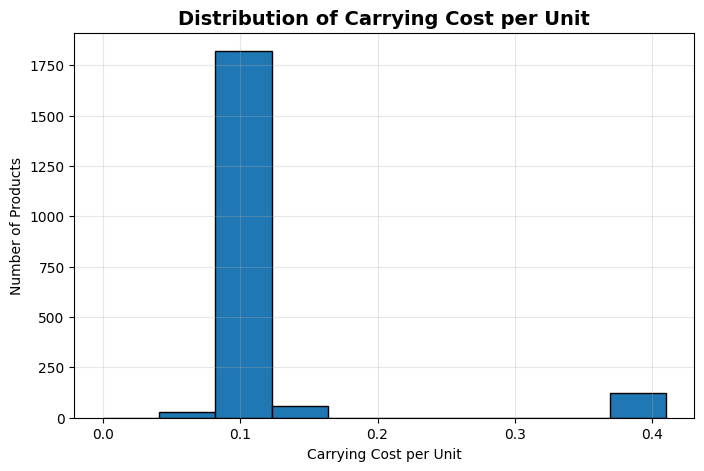

In [15]:

# Distribution of Carrying Cost


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    inventory_df["Carrying_Cost_Per_Unit"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Carrying Cost per Unit",
          fontsize=14,
          weight="bold")

plt.xlabel("Carrying Cost per Unit")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The histogram shows the distribution of inventory carrying cost per unit across all products.

**Key observations:**

- Most products have a carrying cost between **0.09 and 0.11 per unit**, indicating a consistent inventory holding cost for the majority of products.
- Only a small number of products have significantly higher carrying costs, reaching up to **0.41 per unit**.
- The distribution is positively skewed, with a few high-cost products acting as outliers.

Overall, the organisation maintains relatively stable carrying costs for most inventory items.

**Business Insight**

Products with unusually high carrying costs should be reviewed to determine whether their storage requirements, inventory levels or demand justify the additional holding expense. Reducing excess inventory for these products can lower overall inventory costs.

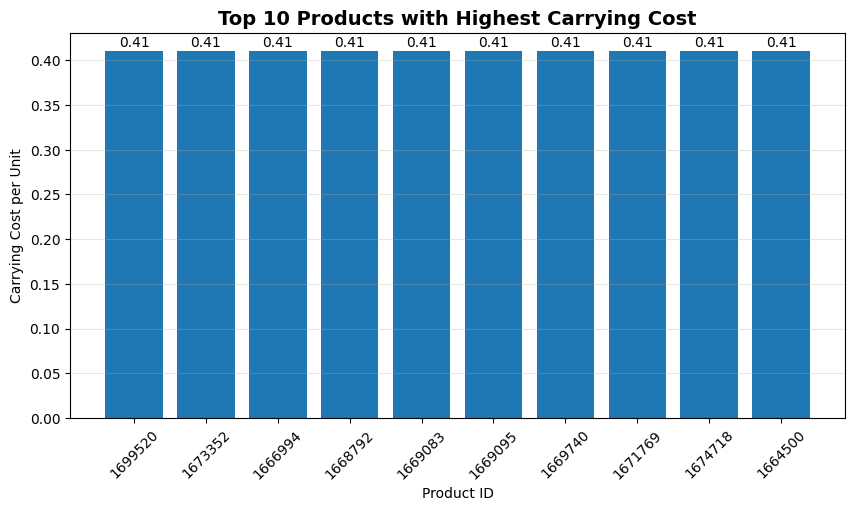

,Product_ID,Carrying_Cost_Per_Unit
32,1699520,0.41
30,1673352,0.41
23,1666994,0.41
24,1668792,0.41
25,1669083,0.41
26,1669095,0.41
27,1669740,0.41
29,1671769,0.41
31,1674718,0.41
22,1664500,0.41


In [16]:

# Top 10 Products with Highest Carrying Cost


top_cost = (
    inventory_df[
        ["Product_ID","Carrying_Cost_Per_Unit"]
    ]
    .sort_values(
        by="Carrying_Cost_Per_Unit",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    top_cost["Product_ID"].astype(str),
    top_cost["Carrying_Cost_Per_Unit"]
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.005,
        round(bar.get_height(),2),
        ha='center',
        fontsize=10
    )

plt.title("Top 10 Products with Highest Carrying Cost",
          fontsize=14,
          weight='bold')

plt.xlabel("Product ID")
plt.ylabel("Carrying Cost per Unit")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

top_cost

### Interpretation

The chart identifies the ten products with the highest inventory carrying cost.

**Key observations:**

- All ten products have the maximum carrying cost of **0.41 per unit**.
- These products represent the most expensive inventory items to maintain in storage.
- Since all top products share the same carrying cost, they should receive equal attention during inventory cost optimisation.

These products should be monitored regularly to ensure that high carrying costs are justified by business demand.

**Business Insight**

Maintaining large quantities of high-cost inventory can increase operational expenses. Inventory managers should regularly review stock levels of these products and optimise replenishment strategies to minimise unnecessary holding costs.

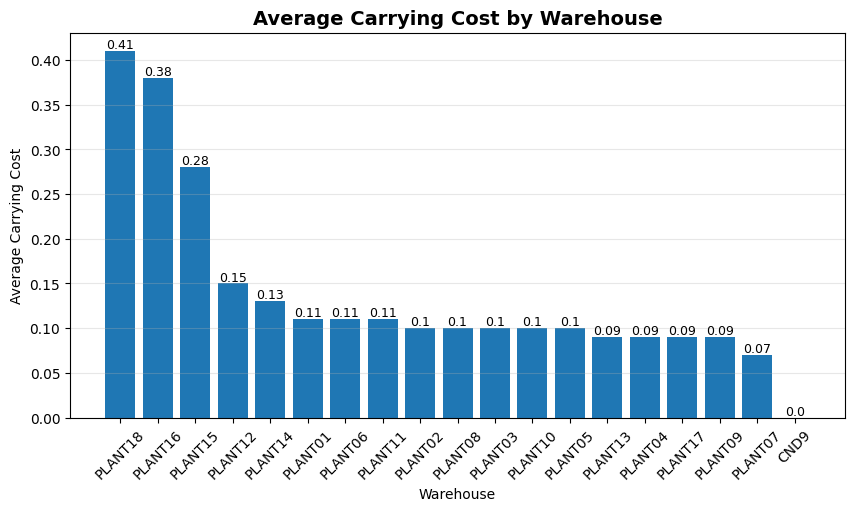

,Carrying_Cost_Per_Unit
Warehouse_ID,
PLANT18,0.41
PLANT16,0.38
PLANT15,0.28
PLANT12,0.15
PLANT14,0.13
PLANT01,0.11
PLANT06,0.11
PLANT11,0.11
PLANT02,0.10


In [17]:

# Warehouse-wise Average Carrying Cost


warehouse_cost = (
    inventory_df
    .groupby("Warehouse_ID")["Carrying_Cost_Per_Unit"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    warehouse_cost.index,
    warehouse_cost.values
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.003,
        round(bar.get_height(),2),
        ha='center',
        fontsize=9
    )

plt.title("Average Carrying Cost by Warehouse",
          fontsize=14,
          weight="bold")

plt.xlabel("Warehouse")
plt.ylabel("Average Carrying Cost")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

warehouse_cost

### Interpretation

The warehouse-wise analysis compares the average carrying cost across different warehouse locations.

**Key observations:**

- **PLANT18** has the highest average carrying cost (**0.41 per unit**).
- **PLANT16** follows with an average carrying cost of **0.38 per unit**.
- Most warehouses maintain carrying costs close to **0.09–0.11 per unit**.
- **CND9** has an average carrying cost of **0**, indicating that no inventory is currently stored in this location.

The variation in carrying cost suggests that inventory storage expenses differ across warehouses.

**Business Insight**

Warehouses with higher carrying costs should be evaluated to identify opportunities for inventory optimisation, improved storage utilisation and cost reduction. Balancing inventory across warehouses may help reduce overall storage expenses.

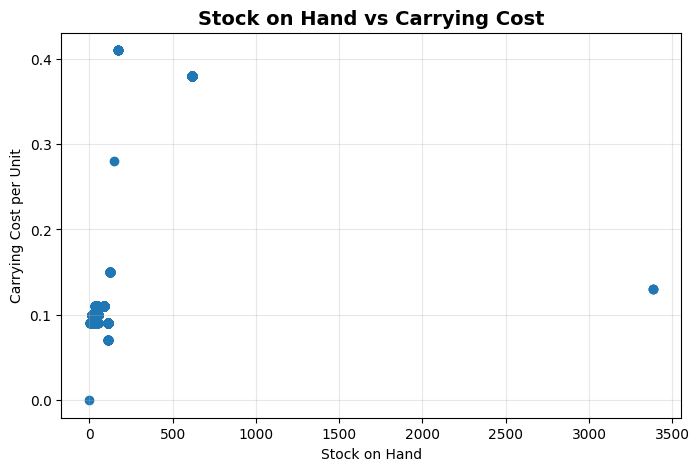

In [18]:

# Stock vs Carrying Cost

plt.figure(figsize=(8,5))

plt.scatter(
    inventory_df["Stock_On_Hand"],
    inventory_df["Carrying_Cost_Per_Unit"]
)

plt.title("Stock on Hand vs Carrying Cost",
          fontsize=14,
          weight="bold")

plt.xlabel("Stock on Hand")
plt.ylabel("Carrying Cost per Unit")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The scatter plot illustrates the relationship between available stock and inventory carrying cost.

**Key observations:**

- Most products have relatively low stock quantities with carrying costs ranging between **0.09 and 0.11 per unit**.
- A few products exhibit significantly higher carrying costs despite moderate inventory levels.
- The product with the highest stock quantity (**approximately 3,385 units**) has a carrying cost of approximately **0.13 per unit**.
- No strong linear relationship is observed between stock quantity and carrying cost.

The analysis indicates that carrying cost is influenced by factors beyond stock quantity alone.

**Business Insight**

Increasing inventory quantity does not necessarily result in higher carrying costs. Other operational factors such as storage conditions, product characteristics and warehouse policies may significantly influence inventory holding costs.

In [19]:

# Carrying Cost Statistics


inventory_df["Carrying_Cost_Per_Unit"].describe()

,Carrying_Cost_Per_Unit
count,2036.000000
mean,0.118571
std,0.068646
min,0.000000
25%,0.100000
50%,0.100000
75%,0.110000
max,0.410000


### Interpretation

The descriptive statistics summarise the overall carrying cost of inventory.

**Key observations:**

- The average carrying cost per unit is **0.119**.
- The minimum carrying cost is **0.00**, while the maximum is **0.41**.
- Half of the products have carrying costs of **0.10 or lower**.
- The relatively small standard deviation (**0.069**) indicates that most products have similar carrying costs, with only a few high-cost outliers.

Overall, carrying costs remain stable for the majority of inventory items.

**Business Insight**

The organisation maintains a consistent inventory carrying cost structure. However, products with significantly higher carrying costs should be monitored carefully to improve cost efficiency and inventory profitability.

# Carrying Cost Analysis Summary

The carrying cost analysis evaluated inventory holding expenses across products and warehouses.

### Key Findings

- Most products have carrying costs between **0.09 and 0.11 per unit**.
- The maximum carrying cost observed is **0.41 per unit**.
- PLANT18 records the highest average carrying cost, followed by PLANT16.
- No strong relationship exists between stock quantity and carrying cost.
- Only a few products contribute to significantly higher inventory holding expenses.

Overall, the organisation maintains a stable carrying cost structure while providing opportunities to optimise storage expenses for selected high-cost products.

# Overall Business Insights

Based on the inventory analysis, the following key business insights were identified:

### 1. Healthy Inventory Levels
The majority of products maintain sufficient stock levels, indicating effective inventory planning and control.

### 2. Uneven Stock Distribution
Inventory is not evenly distributed across products. A small number of products maintain exceptionally high stock quantities, while most products have relatively low inventory levels.

### 3. Warehouse Inventory Imbalance
PLANT16 stores the largest share of inventory, whereas several warehouses maintain considerably lower stock levels. This indicates opportunities for better inventory balancing.

### 4. Low Reorder Requirement
Only **21 out of 2,036 products (approximately 1%)** require immediate replenishment, reflecting efficient inventory monitoring practices.

### 5. PLANT17 Requires Immediate Attention
Nearly all products requiring replenishment belong to PLANT17, making it the highest priority warehouse for inventory restocking.

### 6. Standardised Lead Time
Every product has a consistent supplier lead time of **5 days**, simplifying procurement planning and inventory scheduling.

### 7. Stable Carrying Costs
Most products incur carrying costs between **0.09 and 0.11 per unit**, indicating a stable inventory holding cost structure.

### 8. High Carrying Cost Products
A small number of products have significantly higher carrying costs (**0.41 per unit**) and should be reviewed to optimise inventory expenses.

### 9. Weak Relationship Between Stock and Carrying Cost
Higher stock quantities do not necessarily result in higher carrying costs, suggesting that other operational factors also influence inventory holding expenses.

### 10. Overall Inventory Performance
The organisation demonstrates effective inventory management practices, with opportunities to further optimise warehouse utilisation and inventory cost.

# Business Recommendations

Based on the analysis, the following recommendations are proposed to improve inventory management and operational efficiency:

### 1.
Prioritise replenishment activities for the 21 products identified below the reorder level.

### 2.
Focus immediate inventory planning efforts on PLANT17 to eliminate stock shortages.

### 3.
Redistribute inventory across warehouses to reduce dependency on PLANT16 and improve warehouse utilisation.

### 4.
Regularly review products with exceptionally high stock quantities to minimise unnecessary carrying costs.

### 5.
Monitor high carrying cost products and optimise their inventory levels based on demand forecasts.

### 6.
Implement automated inventory monitoring dashboards to continuously track stock availability and reorder requirements.

### 7.
Periodically review warehouse inventory distribution to improve operational efficiency.

### 8.
Continue maintaining the current standardised supplier lead time while periodically evaluating supplier performance.

### 9.
Adopt demand-driven inventory planning to balance product availability with inventory holding costs.

### 10.
Perform regular inventory audits to identify slow-moving or excess stock and improve warehouse productivity.

# Conclusion

The inventory analysis successfully evaluated stock availability, reorder trends, lead time and carrying cost using Python and data visualisation techniques.

The analysis showed that the organisation maintains healthy inventory levels, with only a small proportion of products requiring immediate replenishment. Warehouse inventory is concentrated in PLANT16, while PLANT17 requires focused replenishment efforts. Carrying costs remain stable for most products, although a few high-cost items present opportunities for further optimisation.

Overall, the findings demonstrate effective inventory management practices and provide valuable recommendations to improve warehouse utilisation, inventory planning and operational efficiency. These insights support informed decision-making and establish a strong foundation for the next phase of the project, which involves developing an interactive Power BI dashboard.